In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from bs4 import BeautifulSoup
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Conv1D,Flatten,Dense,MaxPool1D,Dropout, SimpleRNN
import tensorflow as tf

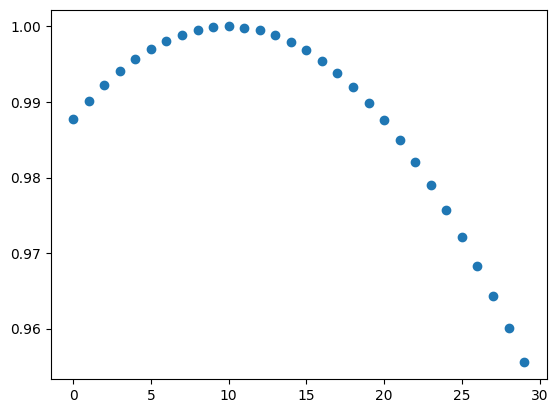

In [45]:
time = np.linspace(0,10*np.pi,2000)
data = np.sin(time)

# plt.figure(figsize=(15,5))
# plt.plot(data, color ='blue')
# plt.show()

plt.scatter(np.arange(30),data[90:120])
plt.show()

In [46]:
seq = 20
x = [] # 20 values
y = [] # 21 value

for i in range(len(data) - seq):
    x.append(data[i:i+seq])
    y.append(data[i+seq])

x = np.array(x)
y = np.array(y)

x = x.reshape((*x.shape,1))
x.shape

(1980, 20, 1)

In [47]:
x_train , x_test = x [:1500],x [1500:]
y_train, y_test = y [:1500],y [1500:]

In [48]:
features = 1
model = Sequential()
model.add(SimpleRNN(units=32,input_shape=(seq,features),activation='tanh'))
model.add(Dense(1,activation='linear'))

model.compile(optimizer=tf._optimizers.Adam(),loss=tf.losses.mean_absolute_error)
model.fit(x_train, y_train, batch_size=25,epochs=10, validation_data=(x_test,y_test))


Epoch 1/10
60/60 [==============================] - 7s 33ms/step - loss: 0.1801 - val_loss: 0.0252
Epoch 2/10
60/60 [==============================] - 1s 16ms/step - loss: 0.0213 - val_loss: 0.0187
Epoch 3/10
60/60 [==============================] - 1s 19ms/step - loss: 0.0103 - val_loss: 0.0168
Epoch 4/10
60/60 [==============================] - 1s 18ms/step - loss: 0.0122 - val_loss: 0.0099
Epoch 5/10
60/60 [==============================] - 1s 14ms/step - loss: 0.0075 - val_loss: 0.0034
Epoch 6/10
60/60 [==============================] - 1s 12ms/step - loss: 0.0060 - val_loss: 0.0039
Epoch 7/10
60/60 [==============================] - 1s 19ms/step - loss: 0.0072 - val_loss: 0.0073
Epoch 8/10
60/60 [==============================] - 1s 18ms/step - loss: 0.0091 - val_loss: 0.0142
Epoch 9/10
60/60 [==============================] - 1s 21ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 10/10
60/60 [==============================] - 1s 20ms/step - loss: 0.0074 - val_loss: 0.0051


15/15 [==============================] - 1s 14ms/step


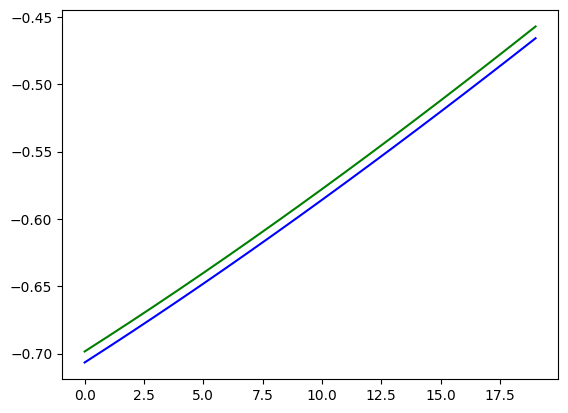

In [49]:
pred = model.predict(x_test)
plt.plot(y_test[30:50], color='green')
plt.plot(pred[30:50],color='blue')
plt.show()

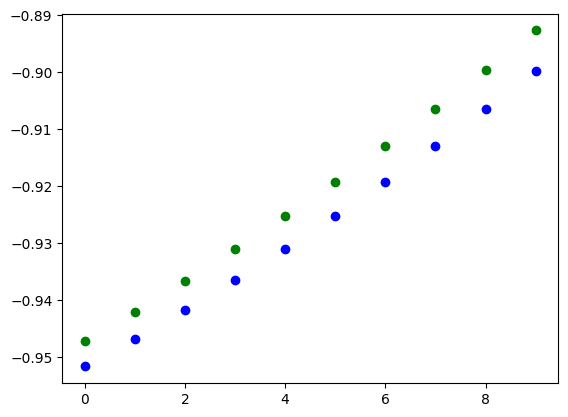

In [50]:
plt.scatter(np.arange(0,10),y_test[:10], color='green')
plt.scatter(np.arange(0,10),pred[:10],color='blue')
plt.show()